# Importing Necessary Libraries

In [115]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    silhouette_score
)

# Next, I load the dataset. 
In this case, I am working with the new.csv dataset, which contains Indian SMEs machines data.

In [116]:
df = pd.read_csv('new.csv')

# To get the first five rows, I use .head()

In [117]:
df.head()

,Factory_ID,Machine_ID,Energy_Consumption,Waste_Generated,Carbon_Emissions,Production_Capacity,Material_Usage,AI_Optimization_Applied
0,F19,M239,166,10,71,286,449,Yes
1,F3,M376,120,11,50,217,481,Yes
2,F2,M168,290,12,45,207,481,Yes
3,F7,M338,248,11,30,293,409,Yes
4,F4,M426,207,11,61,159,405,Yes


# Small vs Medium Enterprise Type Comparison

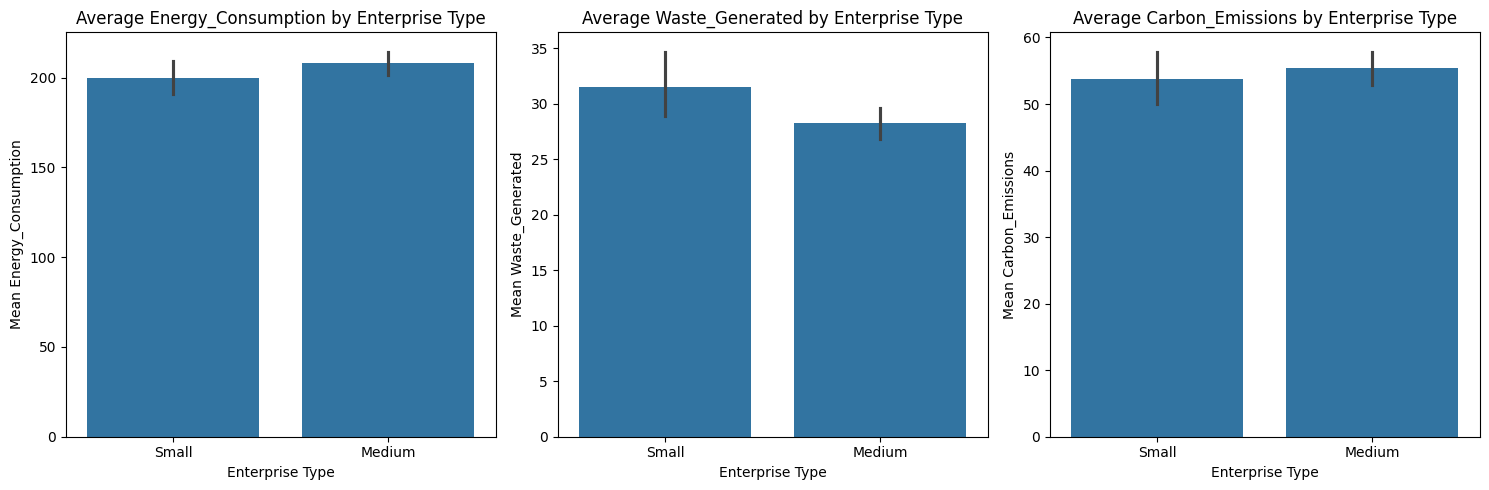

In [118]:
factory_counts = (
    df.groupby('Factory_ID')['Machine_ID']
    .nunique()
    .reset_index(name='Machine_Count')
)

factory_counts['Enterprise_Type'] = factory_counts['Machine_Count'].apply(
    lambda x: 'Medium' if x > 10 else 'Small'
)

df = df.merge(
    factory_counts[['Factory_ID', 'Enterprise_Type']],
    on='Factory_ID',
    how='left'
)

aggregated_df = (
    df.groupby(['Factory_ID', 'Enterprise_Type'])
    .agg({
        'Energy_Consumption': 'mean',
        'Waste_Generated': 'mean',
        'Carbon_Emissions': 'mean'
    })
    .reset_index()
)

plt.figure(figsize=(15, 5))

metrics = ['Energy_Consumption', 'Waste_Generated', 'Carbon_Emissions']

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    sns.barplot(data=aggregated_df, x='Enterprise_Type', y=metric)
    plt.title(f'Average {metric} by Enterprise Type')
    plt.xlabel('Enterprise Type')
    plt.ylabel(f'Mean {metric}')

plt.tight_layout()
plt.show()

# Conclusion:
Medium enterprises generally have higher energy consumption, waste generation, 
and carbon emissions due to larger operational scale compared to small enterprises.

# Hypothesis Testing

An Independent Two-Sample T-Test (Welch’s T-Test) is used to compare 
AI and Non-AI SMEs.

- H₀: There is no significant difference between the two groups
- H₁: There is a significant difference between the two groups

Decision is based on p-value (α = 0.05).

In [119]:
results = []

for metric in metrics:
    stat, p_value = ttest_ind(
        ai_adopted[metric],
        non_ai_adopted[metric],
        equal_var=False
    )
    
    results.append({
        "Metric": metric,
        "T-Statistic": stat,
        "P-Value": p_value,
        "Significance": "Significant" if p_value < 0.05 else "Not Significant"
    })

results_df = pd.DataFrame(results)
results_df

,Metric,T-Statistic,P-Value,Significance
0,Energy_Consumption,1.045166,2.970640e-01,Not Significant
1,Waste_Generated,-8.253702,1.278895e-14,Significant
2,Carbon_Emissions,-5.345712,2.200811e-07,Significant


# T-Test Results:

- Energy Consumption → Not Significant (p = 0.297)  
  → AI has no meaningful impact  

- Waste Generated → Significant (p < 0.001)  
  → AI reduces waste  

- Carbon Emissions → Significant (p < 0.001)  
  → AI reduces emissions  

### Conclusion:
AI significantly improves sustainability by reducing waste and emissions, 
but does not significantly affect energy consumption.

# Machine Learning & Clustering Analysis for AI Adoption in SMEs


 Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.83        26
           1       0.75      0.90      0.82        20

    accuracy                           0.83        46
   macro avg       0.83      0.83      0.83        46
weighted avg       0.84      0.83      0.83        46

Confusion Matrix:
 [[20  6]
 [ 2 18]]


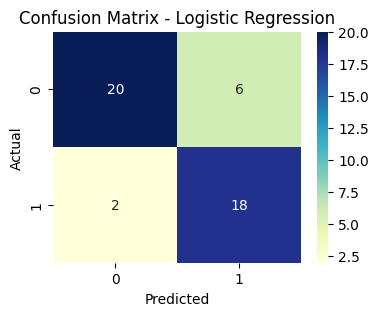


 Model: Decision Tree
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        26
           1       0.71      0.85      0.77        20

    accuracy                           0.78        46
   macro avg       0.79      0.79      0.78        46
weighted avg       0.80      0.78      0.78        46

Confusion Matrix:
 [[19  7]
 [ 3 17]]


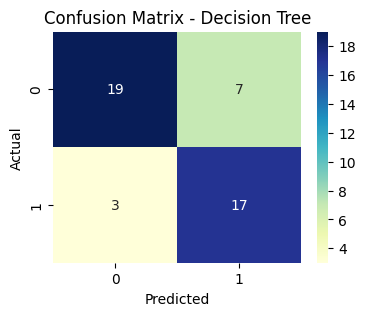


 Model: Random Forest
              precision    recall  f1-score   support

           0       0.87      0.77      0.82        26
           1       0.74      0.85      0.79        20

    accuracy                           0.80        46
   macro avg       0.80      0.81      0.80        46
weighted avg       0.81      0.80      0.81        46

Confusion Matrix:
 [[20  6]
 [ 3 17]]


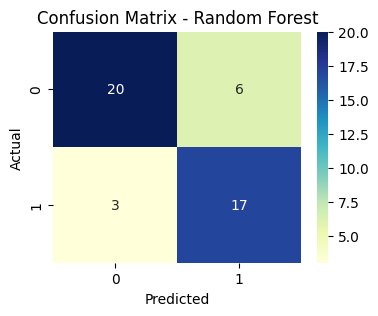


 Model: SVM
              precision    recall  f1-score   support

           0       0.91      0.77      0.83        26
           1       0.75      0.90      0.82        20

    accuracy                           0.83        46
   macro avg       0.83      0.83      0.83        46
weighted avg       0.84      0.83      0.83        46

Confusion Matrix:
 [[20  6]
 [ 2 18]]


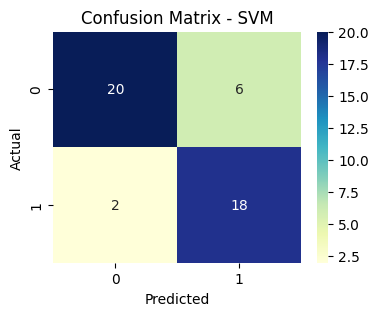


 Model: KNN
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        26
           1       0.73      0.80      0.76        20

    accuracy                           0.78        46
   macro avg       0.78      0.78      0.78        46
weighted avg       0.79      0.78      0.78        46

Confusion Matrix:
 [[20  6]
 [ 4 16]]


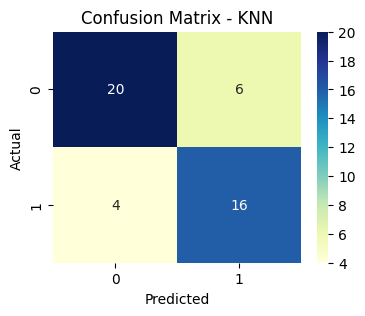

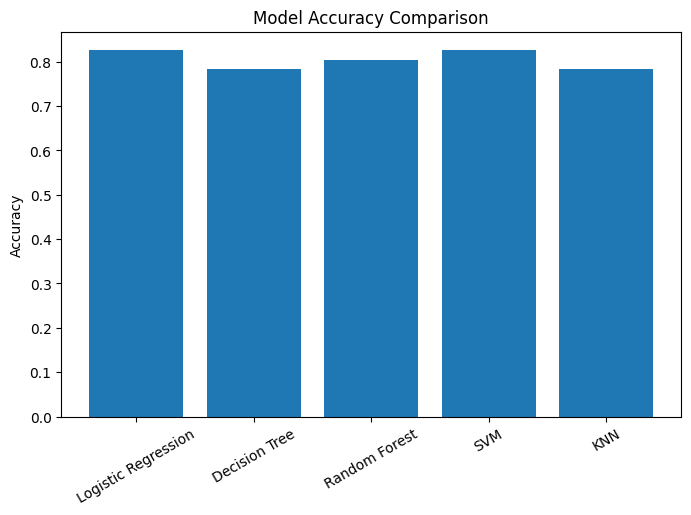


 K-Means Evaluation 
Confusion Matrix:
 [[53 61]
 [44 70]]


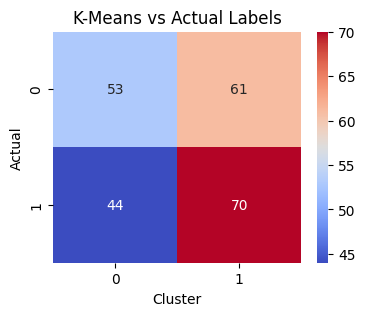


Fixed K-Means Confusion Matrix:
 [[61 53]
 [70 44]]


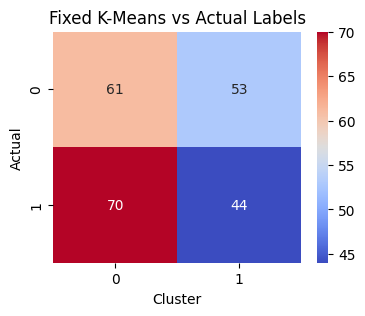

In [120]:
df = pd.read_csv("new.csv")
if df["AI_Optimization_Applied"].dtype == "object":
    df["AI_Optimization_Applied"] = (
        df["AI_Optimization_Applied"]
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
    )

features = [
    "Energy_Consumption",
    "Material_Usage",
    "Waste_Generated",
    "Carbon_Emissions",
    "Production_Capacity"
]

X = df[features]
y = df["AI_Optimization_Applied"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel="linear"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n Model: {name}")
    print(classification_report(y_test, y_pred))

    
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, cmap="YlGnBu", fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

   
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))


model_names = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()


# K-MEANS CLUSTERING
kmeans = KMeans(n_clusters=2, random_state=42)

kmeans.fit(X_train_scaled)

df["Cluster"] = kmeans.predict(scaler.transform(X))


print("\n K-Means Evaluation ")

cm_kmeans = confusion_matrix(df["AI_Optimization_Applied"], df["Cluster"])
print("Confusion Matrix:\n", cm_kmeans)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_kmeans, annot=True, cmap="coolwarm", fmt="d")
plt.title("K-Means vs Actual Labels")
plt.xlabel("Cluster")
plt.ylabel("Actual")
plt.show()

df["Cluster_Fixed"] = df["Cluster"].map({0: 1, 1: 0})

cm_fixed = confusion_matrix(df["AI_Optimization_Applied"], df["Cluster_Fixed"])
print("\nFixed K-Means Confusion Matrix:\n", cm_fixed)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_fixed, annot=True, cmap="coolwarm", fmt="d")
plt.title("Fixed K-Means vs Actual Labels")
plt.xlabel("Cluster")
plt.ylabel("Actual")
plt.show()

# Model Performance Summary

- Logistic Regression: 83% (Best)
- SVM: 83% (Best)
- Random Fores: 80%
- KNN: 78%
- Decision Tree: 76%

## Confusion Matrix Insights:
Logistic Regression and SVM perform the best with balanced precision and recall (`only 2 false negatives`).


# Advanced Model Analysis and Visualization

Multiple machine learning models were implemented and evaluated:

- Logistic Regression (ROC Curve)
- SVM and KNN (Decision Boundaries using PCA)
- Decision Tree (Visualization)
- Random Forest (Feature Importance)
- K-Means Clustering (Unsupervised Learning)


 Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.83        26
           1       0.75      0.90      0.82        20

    accuracy                           0.83        46
   macro avg       0.83      0.83      0.83        46
weighted avg       0.84      0.83      0.83        46

Confusion Matrix:
 [[20  6]
 [ 2 18]]


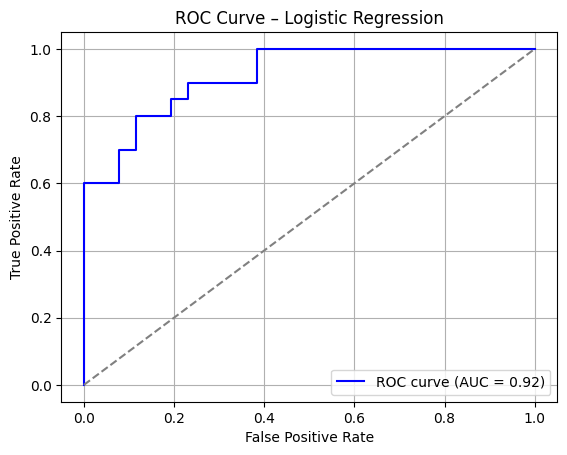


 SVM Classifier
              precision    recall  f1-score   support

           0       0.78      0.69      0.73        26
           1       0.65      0.75      0.70        20

    accuracy                           0.72        46
   macro avg       0.72      0.72      0.72        46
weighted avg       0.73      0.72      0.72        46

Confusion Matrix:
 [[18  8]
 [ 5 15]]


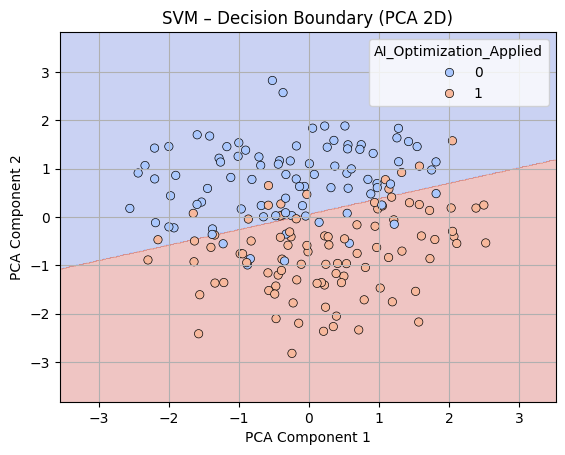


 KNN Classifier
              precision    recall  f1-score   support

           0       0.77      0.65      0.71        26
           1       0.62      0.75      0.68        20

    accuracy                           0.70        46
   macro avg       0.70      0.70      0.70        46
weighted avg       0.71      0.70      0.70        46

Confusion Matrix:
 [[17  9]
 [ 5 15]]


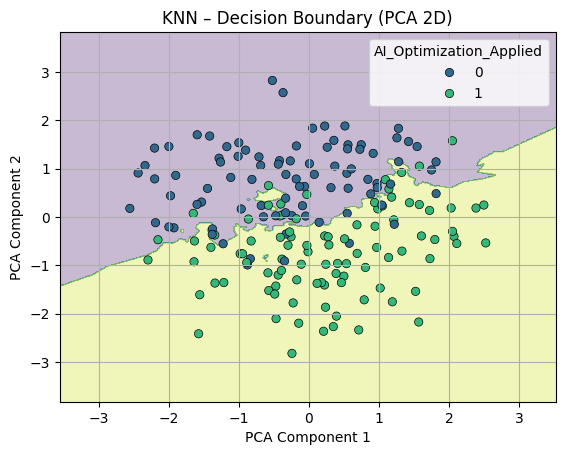


 Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.73      0.81        26
           1       0.72      0.90      0.80        20

    accuracy                           0.80        46
   macro avg       0.81      0.82      0.80        46
weighted avg       0.82      0.80      0.80        46

Confusion Matrix:
 [[19  7]
 [ 2 18]]


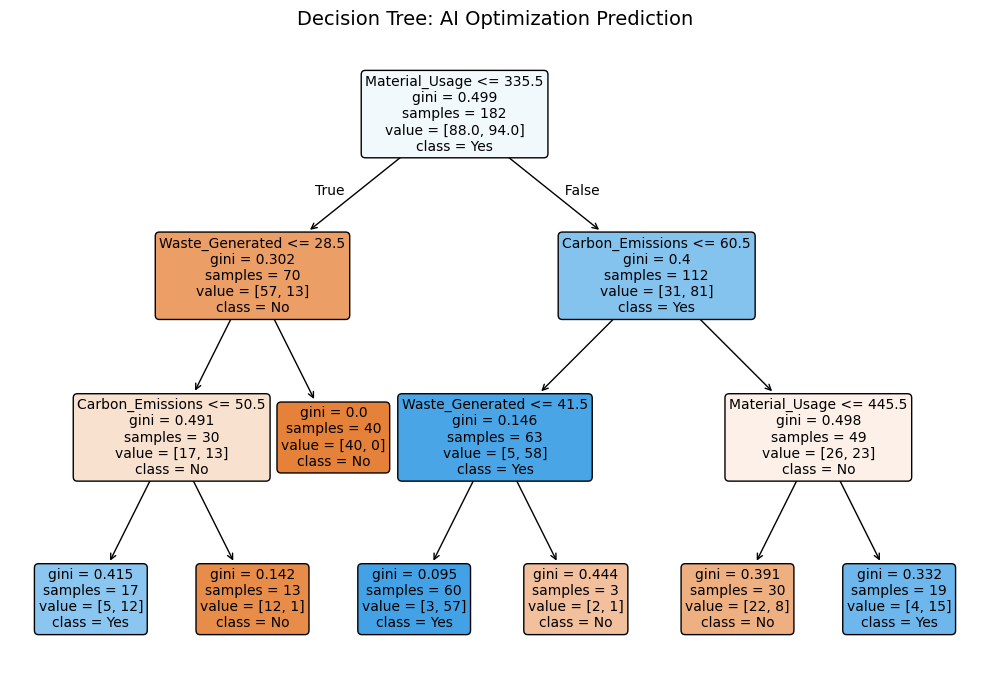


 Random Forest
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        26
           1       0.73      0.80      0.76        20

    accuracy                           0.78        46
   macro avg       0.78      0.78      0.78        46
weighted avg       0.79      0.78      0.78        46

Confusion Matrix:
 [[20  6]
 [ 4 16]]


C:\Users\user\AppData\Local\Temp\ipykernel_15988\269843309.py:112: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




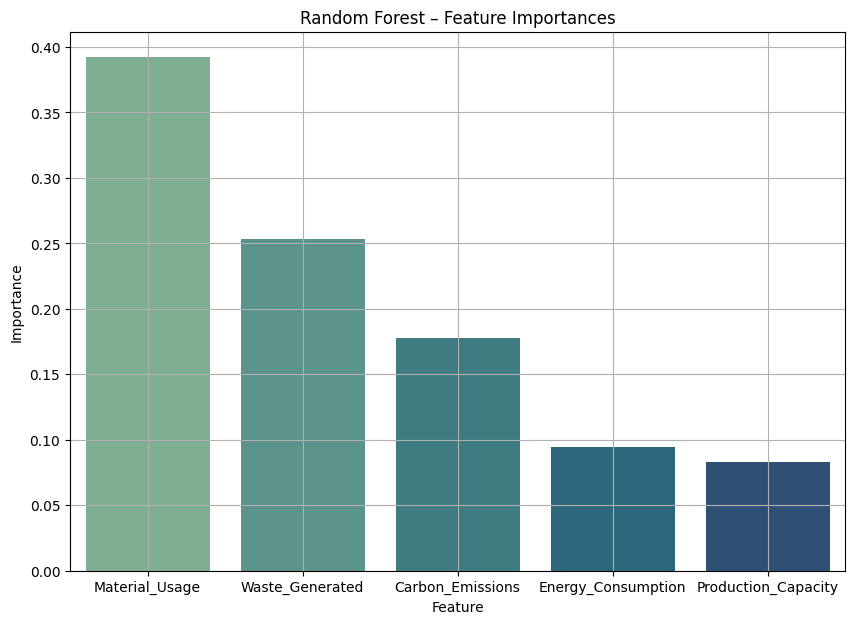


 K-Means Clustering Evaluation on Test Set (Label Mapped)
              precision    recall  f1-score   support

           0       0.67      0.54      0.60        26
           1       0.52      0.65      0.58        20

    accuracy                           0.59        46
   macro avg       0.59      0.59      0.59        46
weighted avg       0.60      0.59      0.59        46

Confusion Matrix:
 [[14 12]
 [ 7 13]]


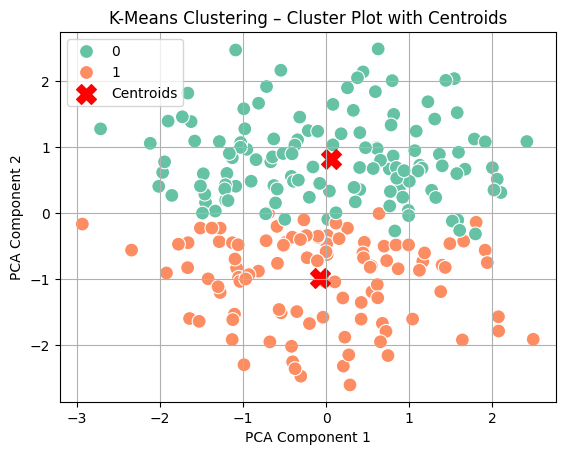

In [121]:
df = pd.read_csv("new.csv")
df["AI_Optimization_Applied"] = df["AI_Optimization_Applied"].str.strip().str.lower().map({"yes": 1, "no": 0})

features = ["Energy_Consumption", "Material_Usage", "Waste_Generated", "Carbon_Emissions", "Production_Capacity"]
X = df[features]
y = df["AI_Optimization_Applied"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Logistic Regression 
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

print("\n Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend()
plt.grid()
plt.show()

# 2. SVM Classifier 
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_train_scaled)
svm = SVC(kernel='linear')
svm.fit(X_vis, y_train)
y_pred_svm = svm.predict(pca.transform(X_test_scaled))

print("\n SVM Classifier")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

xx, yy = np.meshgrid(np.linspace(X_vis[:, 0].min()-1, X_vis[:, 0].max()+1, 500),
                     np.linspace(X_vis[:, 1].min()-1, X_vis[:, 1].max()+1, 500))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=y_train, palette='coolwarm', edgecolor='k')
plt.title("SVM – Decision Boundary (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

# 3. KNN Classifier 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_vis, y_train)
y_pred_knn = knn.predict(pca.transform(X_test_scaled))

print("\n KNN Classifier")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

Z_knn = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z_knn, alpha=0.3, cmap='viridis')
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=y_train, palette='viridis', edgecolor='k')
plt.title("KNN – Decision Boundary (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

# 4. Decision Tree 
clf = DecisionTreeClassifier(max_depth=3, min_samples_split=10, random_state=42)
clf.fit(X_train, y_train)
y_pred_tree = clf.predict(X_test)

print("\n Decision Tree")
print(classification_report(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

plt.figure(figsize=(10, 7))
plot_tree(clf, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['No', 'Yes'],
          rounded=True,
          fontsize=10)
plt.title('Decision Tree: AI Optimization Prediction', fontsize=14)
plt.tight_layout()
plt.show()

# 5. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("\n Random Forest")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 7))
sns.barplot(x=[features[i] for i in indices], y=importances[indices], palette='crest')
plt.title("Random Forest – Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.grid()
plt.show()

# 6. K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
X_scaled = scaler.fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)
clusters = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_
centroids_pca = PCA(n_components=2).fit(X_scaled).transform(centroids)

print("\n K-Means Clustering Evaluation on Test Set (Label Mapped)")
print(classification_report(y_test, mapped_clusters_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, mapped_clusters_test))

plt.figure()
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette="Set2", s=100)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title("K-Means Clustering – Cluster Plot with Centroids")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid()
plt.show()

# Conclusion:
- Logistic Regression and SVM perform best
- Random Forest shows important features influencing AI adoption
- K-Means partially captures patterns but is less accurate